# Tropical Cyclone Track & Intensity Prediction — Full KPI Coverage

**Dataset:** TCIR (Tropical Cyclone Image Repository) — 3 HDF5 files  
**Models:** CNN (single-image) + ConvLSTM (4-frame sequence)  
**KPIs Covered:**

| Category | KPI | Source |
|---|---|---|
| Storm-specific | MSW (knots) — intensity target | TCIR info[:,3] |
| Storm-specific | MCP (hPa) — pressure feature | TCIR info[:,4] |
| Storm-specific | Storm center lat/lon — track target | TCIR info[:,1:3] |
| Storm-specific | Translation speed & direction | Derived from lat/lon + timestamps |
| Storm-specific | RMW proxy | Derived from IR image radial gradient |
| Environmental | SST signal (IR ch0) | TCIR matrix channel 0 |
| Environmental | WV / mid-level moisture (ch2) | TCIR matrix channel 2 |
| Environmental | Vertical wind shear proxy | Derived from TCIR multi-channel texture |
| Large-scale | ENSO state | Matched from NOAA ERSSTv5 Niño3.4 index |
| Large-scale | MJO phase | Matched from NOAA CPC RMM index |

## Cell 1 — Mount Drive, Imports & Memory Check

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import h5py
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import psutil
import os
import tarfile
import gc
import urllib.request
from io import StringIO

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

available_gb = psutil.virtual_memory().available / 1e9
total_gb     = psutil.virtual_memory().total / 1e9
print(f'\nRAM — Available: {available_gb:.1f} GB / Total: {total_gb:.1f} GB')

if available_gb < 6:
    print('WARNING: Less than 6 GB RAM. Go to Runtime -> Change runtime type -> High-RAM.')
else:
    print('RAM looks sufficient — proceeding.')

# ── Paths ──────────────────────────────────────────────────────
DRIVE_TCIR_DIR = '/content/drive/MyDrive/TCIR'
EXTRACT_DIR    = '/content/tcir_extracted'
os.makedirs(EXTRACT_DIR, exist_ok=True)

TAR_FILES = [
    'TCIR-ALL_2017.h5.tar.gz',
    'TCIR-ATLN_EPAC_WPAC.h5.tar.gz',
    'TCIR-CPAC_IO_SH.h5.tar.gz',
]

extracted_h5_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith('.h5'):
            extracted_h5_files.append(os.path.join(root, f))

if len(extracted_h5_files) == 3:
    print(f'\nFound 3 .h5 files already — skipping extraction.')
    extracted_h5_files = sorted(extracted_h5_files)
else:
    extracted_h5_files = []
    for tar_name in TAR_FILES:
        tar_path = os.path.join(DRIVE_TCIR_DIR, tar_name)
        if not os.path.exists(tar_path):
            print(f'WARNING: {tar_name} not found — skipping.')
            continue
        print(f'Extracting {tar_name} ...')
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(EXTRACT_DIR)
        print(f'  Done -> {EXTRACT_DIR}')

    for root, dirs, files in os.walk(EXTRACT_DIR):
        for f in files:
            if f.endswith('.h5'):
                extracted_h5_files.append(os.path.join(root, f))
    extracted_h5_files = sorted(extracted_h5_files)

print(f'\nFound {len(extracted_h5_files)} .h5 file(s):')
for p in extracted_h5_files:
    print(f'  {p}')

Mounted at /content/drive
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

RAM — Available: 11.6 GB / Total: 13.6 GB
RAM looks sufficient — proceeding.
Extracting TCIR-ALL_2017.h5.tar.gz ...


/tmp/ipykernel_1513/108513682.py:62: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


  Done -> /content/tcir_extracted
Extracting TCIR-ATLN_EPAC_WPAC.h5.tar.gz ...
  Done -> /content/tcir_extracted
Extracting TCIR-CPAC_IO_SH.h5.tar.gz ...
  Done -> /content/tcir_extracted

Found 3 .h5 file(s):
  /content/tcir_extracted/TCIR-ALL_2017.h5
  /content/tcir_extracted/TCIR-ATLN_EPAC_WPAC.h5
  /content/tcir_extracted/TCIR-CPAC_IO_SH.h5


## Cell 2 — Inspect HDF5 Structure

In [2]:
def inspect_h5(path):
    with h5py.File(path, 'r') as f:
        print(f'--- File Structure: {path} ---')
        def print_item(name, obj):
            print(f'  {name} : {type(obj).__name__}')
            if isinstance(obj, h5py.Dataset):
                print(f'    -> Shape: {obj.shape}, dtype: {obj.dtype}')
        f.visititems(print_item)

        # Print column names for info block
        if 'info/axis0' in f:
            cols = [b.decode() if isinstance(b, bytes) else b for b in f['info/axis0'][:]]
            print(f'  info columns: {cols}')

for h5_path in extracted_h5_files:
    inspect_h5(h5_path)
    print()

--- File Structure: /content/tcir_extracted/TCIR-ALL_2017.h5 ---
  info : Group
  info/axis0 : Dataset
    -> Shape: (8,), dtype: |S9
  info/axis1 : Dataset
    -> Shape: (4580,), dtype: int64
  info/block0_items : Dataset
    -> Shape: (5,), dtype: |S9
  info/block0_values : Dataset
    -> Shape: (4580, 5), dtype: float64
  info/block1_items : Dataset
    -> Shape: (3,), dtype: |S8
  info/block1_values : Dataset
    -> Shape: (1,), dtype: object
  matrix : Dataset
    -> Shape: (4580, 201, 201, 4), dtype: float32
  info columns: ['data_set', 'ID', 'lon', 'lat', 'time', 'Vmax', 'R35_4qAVG', 'MSLP']

--- File Structure: /content/tcir_extracted/TCIR-ATLN_EPAC_WPAC.h5 ---
  info : Group
  info/axis0 : Dataset
    -> Shape: (8,), dtype: |S9
  info/axis1 : Dataset
    -> Shape: (47381,), dtype: int64
  info/block0_items : Dataset
    -> Shape: (5,), dtype: |S9
  info/block0_values : Dataset
    -> Shape: (47381, 5), dtype: float64
  info/block1_items : Dataset
    -> Shape: (3,), dtype: |S8

## Cell 3 — Download & Build KPI Scalar Features

This cell fetches free NOAA index data to cover the large-scale pattern KPIs:
- **ENSO** — Niño3.4 SST anomaly (monthly) from NOAA ERSSTv5
- **MJO phase** — Real-time Multivariate MJO (RMM) index from NOAA CPC

These are joined to each storm observation by year+month (ENSO) and date (MJO).

In [3]:
# ── ENSO: Niño3.4 index (monthly) ─────────────────────────────
# Source: NOAA CPC — https://www.cpc.ncep.noaa.gov/data/indices/sstoi.indices
ENSO_URL = 'https://www.cpc.ncep.noaa.gov/data/indices/sstoi.indices'

try:
    with urllib.request.urlopen(ENSO_URL, timeout=15) as r:
        enso_raw = r.read().decode('utf-8')
    # The file is fixed-width: Year Mon Nino1+2 Anom Nino3 Anom Nino4 Anom Nino3.4 Anom
    enso_rows = []
    for line in enso_raw.strip().split('\n'):
        parts = line.split()
        if len(parts) >= 10 and parts[0].isdigit():
            yr, mo = int(parts[0]), int(parts[1])
            nino34_anom = float(parts[9])   # column index 9 = Nino3.4 anomaly
            enso_rows.append({'year': yr, 'month': mo, 'nino34': nino34_anom})
    enso_df = pd.DataFrame(enso_rows)
    print(f'ENSO data loaded: {len(enso_df)} monthly records')
    print(enso_df.head())
except Exception as e:
    print(f'ENSO download failed ({e}) — using zero placeholder.')
    # Build a fallback DataFrame covering 1980-2025 filled with zeros
    rows = []
    for yr in range(1980, 2026):
        for mo in range(1, 13):
            rows.append({'year': yr, 'month': mo, 'nino34': 0.0})
    enso_df = pd.DataFrame(rows)

# ── MJO: RMM index (daily) ─────────────────────────────────────
# Source: NOAA CPC — https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_mjo_index/rmm.74toRealtime.txt
MJO_URL = 'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_mjo_index/rmm.74toRealtime.txt'

try:
    with urllib.request.urlopen(MJO_URL, timeout=15) as r:
        mjo_raw = r.read().decode('utf-8')
    mjo_rows = []
    for line in mjo_raw.strip().split('\n'):
        parts = line.split()
        # Format: year month day RMM1 RMM2 phase amplitude
        if len(parts) >= 7 and parts[0].isdigit():
            try:
                yr, mo, dy = int(parts[0]), int(parts[1]), int(parts[2])
                rmm1  = float(parts[3])
                rmm2  = float(parts[4])
                phase = int(float(parts[5]))  # MJO phase 1-8
                amp   = float(parts[6])       # MJO amplitude
                mjo_rows.append({
                    'year': yr, 'month': mo, 'day': dy,
                    'rmm1': rmm1, 'rmm2': rmm2,
                    'mjo_phase': phase, 'mjo_amp': amp
                })
            except:
                pass
    mjo_df = pd.DataFrame(mjo_rows)
    # Encode phase as sin/cos to preserve cyclical structure
    mjo_df['mjo_sin'] = np.sin(2 * np.pi * mjo_df['mjo_phase'] / 8)
    mjo_df['mjo_cos'] = np.cos(2 * np.pi * mjo_df['mjo_phase'] / 8)
    print(f'MJO data loaded: {len(mjo_df)} daily records')
    print(mjo_df.head())
except Exception as e:
    print(f'MJO download failed ({e}) — using zero placeholder.')
    rows = []
    for yr in range(1974, 2026):
        for mo in range(1, 13):
            for dy in range(1, 29):
                rows.append({'year': yr, 'month': mo, 'day': dy,
                             'rmm1': 0.0, 'rmm2': 0.0,
                             'mjo_phase': 1, 'mjo_amp': 0.0,
                             'mjo_sin': 0.0, 'mjo_cos': 1.0})
    mjo_df = pd.DataFrame(rows)

print('\nKPI index tables ready.')

ENSO data loaded: 531 monthly records
   year  month  nino34
0  1982      1    0.08
1  1982      2   -0.20
2  1982      3   -0.14
3  1982      4    0.02
4  1982      5    0.49
MJO download failed (HTTP Error 404: Not Found) — using zero placeholder.

KPI index tables ready.


## Cell 4 — KPI-Complete Data Loader

This is the core loader. For each sample it extracts:

**From TCIR info block:**
- `lat`, `lon` — storm center position (track target)
- `vmax` — maximum sustained wind speed in knots (intensity target)
- `mcp` — minimum central pressure in hPa (feature + intensity proxy)
- `storm_id`, `timestamp`

**Derived scalars (no external data needed):**
- `translation_speed`, `translation_dir` — computed from consecutive lat/lon + Δt
- `rmw_proxy` — radial gradient of IR channel as a structural RMW estimate
- `shear_proxy` — difference between upper (ch1=WV) and lower (ch0=IR) spatial variance
- `sst_mean` — mean of IR channel (ch0) as SST proxy

**Joined from NOAA index files:**
- `nino34` — ENSO state matched by year+month
- `mjo_sin`, `mjo_cos`, `mjo_amp` — MJO phase & amplitude matched by date

In [4]:
def decode_timestamp(ts):
    """Convert TCIR integer timestamp (YYYYMMDDHH) to year, month, day."""
    ts = int(ts)
    yr  = ts // 1000000
    mo  = (ts % 1000000) // 10000
    dy  = (ts % 10000) // 100
    return yr, mo, dy

def compute_rmw_proxy(ir_img):
    """Estimate RMW as the radius of steepest radial IR gradient from image center."""
    h, w = ir_img.shape
    cy, cx = h // 2, w // 2
    max_r = min(cy, cx)
    radial_means = []
    for r in range(2, max_r):
        mask = np.zeros((h, w), dtype=bool)
        y_idx, x_idx = np.ogrid[:h, :w]
        ring = ((y_idx - cy)**2 + (x_idx - cx)**2 >= (r-1)**2) & \
               ((y_idx - cy)**2 + (x_idx - cx)**2 < r**2)
        radial_means.append(ir_img[ring].mean() if ring.any() else 0)
    if len(radial_means) < 2:
        return 0.0
    grad = np.abs(np.diff(radial_means))
    return float(np.argmax(grad) + 2)  # pixel radius of max gradient

def compute_shear_proxy(img_4ch):
    """
    Vertical wind shear proxy: difference in spatial variance between
    upper-level (WV, ch2) and lower-level (IR, ch0) texture.
    Higher difference = more shear-like environment.
    """
    upper_var = float(np.var(img_4ch[:, :, 2]))  # WV = upper moisture
    lower_var = float(np.var(img_4ch[:, :, 0]))  # IR = surface/lower
    return upper_var - lower_var


def load_single_h5_kpi(file_path, target_size=(64, 64), chunk_size=500):
    """Load TCIR h5 file and extract all KPI features."""
    with h5py.File(file_path, 'r') as f:
        info = f['info/block0_values'][:]
        # TCIR info columns: storm_id, lat, lon, vmax, mcp (+ others)
        storm_ids  = info[:, 0].astype('float32')
        lats       = info[:, 1].astype('float32')
        lons       = info[:, 2].astype('float32')
        vmax       = info[:, 3].astype('float32')   # MSW — intensity target
        mcp        = info[:, 4].astype('float32') if info.shape[1] > 4 else np.zeros(len(info), dtype='float32')

        # Try to read timestamps from axis1 (integer YYYYMMDDHH)
        if 'info/axis1' in f:
            timestamps = f['info/axis1'][:].astype('float64')
        else:
            timestamps = np.zeros(len(info), dtype='float64')

        # Filter out bad labels
        valid_mask = (vmax >= 5) & (vmax <= 200) & np.isfinite(lats) & np.isfinite(lons)
        valid_idx  = np.where(valid_mask)[0]
        N = len(valid_idx)
        print(f'  Valid samples: {N} (removed {(~valid_mask).sum()} bad)')

        vmax       = vmax[valid_mask]
        mcp        = mcp[valid_mask]
        lats       = lats[valid_mask]
        lons       = lons[valid_mask]
        storm_ids  = storm_ids[valid_mask]
        timestamps = timestamps[valid_mask]

        # Channel medians for NaN fill
        sample_idx = valid_idx[:min(500, N)]
        channel_medians = []
        for c in range(4):
            samp = f['matrix'][sample_idx, :, :, c].astype('float32')
            channel_medians.append(float(np.nanmedian(samp)))
            del samp

        # Pre-allocate arrays
        images      = np.zeros((N, target_size[0], target_size[1], 4), dtype='float16')
        rmw_proxy   = np.zeros(N, dtype='float32')
        shear_proxy = np.zeros(N, dtype='float32')
        sst_mean    = np.zeros(N, dtype='float32')

        for start in range(0, N, chunk_size):
            end       = min(start + chunk_size, N)
            batch_idx = valid_idx[start:end]
            raw_chunk = f['matrix'][batch_idx].astype('float32')

            if start % 5000 == 0:
                print(f'    Processing {start}/{N}...')

            for ci in range(end - start):
                img4 = raw_chunk[ci]
                for c in range(4):
                    ch = img4[:, :, c]
                    ch = np.where(np.isnan(ch), channel_medians[c], ch)
                    p1, p99 = np.percentile(ch, [1, 99])
                    ch = np.clip(ch, p1, p99)
                    img4[:, :, c] = ch

                # Derive scalar KPIs from raw full-res image
                ir_resized = cv2.resize(img4[:, :, 0], (32, 32), interpolation=cv2.INTER_AREA)
                rmw_proxy[start + ci]   = compute_rmw_proxy(ir_resized)
                shear_proxy[start + ci] = compute_shear_proxy(img4)
                sst_mean[start + ci]    = float(np.mean(img4[:, :, 0]))

                # Resize to target for CNN input
                for c in range(4):
                    images[start + ci, :, :, c] = cv2.resize(
                        img4[:, :, c], target_size, interpolation=cv2.INTER_AREA
                    ).astype('float16')

            del raw_chunk
            gc.collect()

    return {
        'images':      images,
        'vmax':        vmax,
        'mcp':         mcp,
        'lats':        lats,
        'lons':        lons,
        'storm_ids':   storm_ids,
        'timestamps':  timestamps,
        'rmw_proxy':   rmw_proxy,
        'shear_proxy': shear_proxy,
        'sst_mean':    sst_mean,
    }


def compute_translation_vectors(lats, lons, timestamps, storm_ids):
    """
    KPI: Storm translation speed (kt) and direction (degrees from North).
    Computed storm-by-storm from consecutive lat/lon observations.
    First observation of each storm gets the storm's own mean values.
    """
    from math import radians, sin, cos, sqrt, atan2, degrees
    n = len(lats)
    speeds = np.zeros(n, dtype='float32')
    dirs   = np.zeros(n, dtype='float32')  # 0-360 degrees clockwise from N

    for sid in np.unique(storm_ids):
        idx = np.where(storm_ids == sid)[0]
        idx = idx[np.argsort(timestamps[idx])]
        if len(idx) < 2:
            continue
        for k in range(1, len(idx)):
            i0, i1 = idx[k-1], idx[k]
            lat0, lon0 = radians(lats[i0]), radians(lons[i0])
            lat1, lon1 = radians(lats[i1]), radians(lons[i1])
            dt_hr = max((timestamps[i1] - timestamps[i0]) / 1e4, 1e-3)  # hours

            # Haversine distance in nautical miles
            dlat = lat1 - lat0
            dlon = lon1 - lon0
            a = sin(dlat/2)**2 + cos(lat0)*cos(lat1)*sin(dlon/2)**2
            dist_nm = 2 * 3440.065 * sqrt(max(a, 0))  # Earth radius 3440 nm
            speed   = dist_nm / dt_hr                  # knots

            # Bearing
            x = sin(dlon) * cos(lat1)
            y = cos(lat0)*sin(lat1) - sin(lat0)*cos(lat1)*cos(dlon)
            bearing = (degrees(atan2(x, y)) + 360) % 360

            speeds[i1] = min(speed, 80.0)   # cap at 80 kt (sanity)
            dirs[i1]   = bearing

        # First obs gets storm mean
        speeds[idx[0]] = speeds[idx[1:]].mean() if len(idx) > 1 else 0
        dirs[idx[0]]   = dirs[idx[1:]].mean()   if len(idx) > 1 else 0

    # Encode direction as sin/cos to avoid 0/360 discontinuity
    dir_sin = np.sin(np.radians(dirs)).astype('float32')
    dir_cos = np.cos(np.radians(dirs)).astype('float32')
    return speeds, dir_sin, dir_cos


def join_enso_mjo(timestamps, enso_df, mjo_df):
    """Join ENSO + MJO scalars to each observation by date."""
    # Build lookup dicts
    enso_lut = {(r.year, r.month): r.nino34 for _, r in enso_df.iterrows()}
    mjo_lut  = {(r.year, r.month, r.day): (r.mjo_sin, r.mjo_cos, r.mjo_amp)
                for _, r in mjo_df.iterrows()}

    n = len(timestamps)
    nino34   = np.zeros(n, dtype='float32')
    mjo_sin  = np.zeros(n, dtype='float32')
    mjo_cos  = np.ones(n,  dtype='float32')
    mjo_amp  = np.zeros(n, dtype='float32')

    for i, ts in enumerate(timestamps):
        yr, mo, dy = decode_timestamp(ts)
        nino34[i]  = enso_lut.get((yr, mo), 0.0)
        mjo_val    = mjo_lut.get((yr, mo, dy), (0.0, 1.0, 0.0))
        mjo_sin[i], mjo_cos[i], mjo_amp[i] = mjo_val

    return nino34, mjo_sin, mjo_cos, mjo_amp


print('KPI loader functions defined.')

KPI loader functions defined.


## Cell 5 — Load All Files & Build Combined KPI Dataset

In [5]:
all_data = {
    'images': [], 'vmax': [], 'mcp': [], 'lats': [], 'lons': [],
    'storm_ids': [], 'timestamps': [],
    'rmw_proxy': [], 'shear_proxy': [], 'sst_mean': []
}
storm_offset = 0

for i, path in enumerate(extracted_h5_files):
    print(f'\n[{i+1}/{len(extracted_h5_files)}] Loading: {os.path.basename(path)}')
    d = load_single_h5_kpi(path, target_size=(64, 64))

    for k in all_data:
        if k == 'storm_ids':
            all_data[k].append(d[k] + storm_offset)
        else:
            all_data[k].append(d[k])

    storm_offset += int(d['storm_ids'].max()) + 1
    print(f'  Done: {d["images"].shape[0]} samples')
    gc.collect()

# ── Merge ──────────────────────────────────────────────────────
print('\nMerging datasets...')
total_samples = sum(a.shape[0] for a in all_data['images'])
x_data = np.empty((total_samples, 64, 64, 4), dtype='float32')
cur = 0
for arr in all_data['images']:
    n = arr.shape[0]
    x_data[cur:cur+n] = arr
    cur += n

y_vmax       = np.concatenate(all_data['vmax']).astype('float32')
y_mcp        = np.concatenate(all_data['mcp']).astype('float32')
y_lats       = np.concatenate(all_data['lats']).astype('float32')
y_lons       = np.concatenate(all_data['lons']).astype('float32')
storm_ids    = np.concatenate(all_data['storm_ids']).astype('float32')
timestamps   = np.concatenate(all_data['timestamps']).astype('float64')
rmw_proxy    = np.concatenate(all_data['rmw_proxy']).astype('float32')
shear_proxy  = np.concatenate(all_data['shear_proxy']).astype('float32')
sst_mean_arr = np.concatenate(all_data['sst_mean']).astype('float32')
del all_data; gc.collect()

# ── Z-score normalize images ───────────────────────────────────
print('\nNormalizing image channels...')
for c in range(4):
    mu  = np.float32(np.mean(x_data[:, :, :, c]))
    std = np.float32(np.std(x_data[:, :, :, c]))
    print(f'  Ch{c}: mean={mu:.4f}, std={std:.4f}')
    for s in range(0, total_samples, 2000):
        e = min(s + 2000, total_samples)
        x_data[s:e, :, :, c] = (x_data[s:e, :, :, c] - mu) / (std + 1e-5)

# ── Derived KPIs ───────────────────────────────────────────────
print('\nComputing translation speed & direction...')
trans_speed, trans_dir_sin, trans_dir_cos = compute_translation_vectors(
    y_lats, y_lons, timestamps, storm_ids
)

print('Joining ENSO & MJO indices...')
nino34, mjo_sin, mjo_cos, mjo_amp = join_enso_mjo(timestamps, enso_df, mjo_df)

# ── Normalize MCP ─────────────────────────────────────────────
mcp_valid = y_mcp[y_mcp > 0]
mcp_mu  = mcp_valid.mean() if len(mcp_valid) > 0 else 980.0
mcp_std = mcp_valid.std()  if len(mcp_valid) > 0 else 30.0
y_mcp_norm = np.where(y_mcp > 0, (y_mcp - mcp_mu) / (mcp_std + 1e-5), 0.0).astype('float32')

# ── Build scalar feature matrix (10 features covering remaining KPIs) ──
# [mcp_norm, rmw_proxy_norm, shear_proxy_norm, sst_mean_norm,
#  trans_speed_norm, trans_dir_sin, trans_dir_cos,
#  nino34_norm, mjo_sin, mjo_cos, mjo_amp_norm]
def norm(arr):
    mu, sd = arr.mean(), arr.std()
    return ((arr - mu) / (sd + 1e-5)).astype('float32')

scalar_features = np.stack([
    y_mcp_norm,          # MCP — pressure KPI
    norm(rmw_proxy),     # RMW proxy KPI
    norm(shear_proxy),   # Wind shear proxy KPI
    norm(sst_mean_arr),  # SST mean KPI
    norm(trans_speed),   # Translation speed KPI
    trans_dir_sin,       # Translation direction (sin) KPI
    trans_dir_cos,       # Translation direction (cos) KPI
    norm(nino34),        # ENSO KPI
    mjo_sin,             # MJO phase (sin) KPI
    mjo_cos,             # MJO phase (cos) KPI
    norm(mjo_amp),       # MJO amplitude KPI
], axis=1)  # shape: (N, 11)

# ── Target arrays ─────────────────────────────────────────────
# Intensity: vmax (knots)
# Track: lat/lon delta to next observation (one-step-ahead)
print('\nComputing track targets (lat/lon delta per storm)...')
dlat = np.zeros_like(y_lats)
dlon = np.zeros_like(y_lons)
for sid in np.unique(storm_ids):
    idx = np.where(storm_ids == sid)[0]
    idx = idx[np.argsort(timestamps[idx])]
    for k in range(len(idx) - 1):
        dlat[idx[k]] = y_lats[idx[k+1]] - y_lats[idx[k]]
        dlon[idx[k]] = y_lons[idx[k+1]] - y_lons[idx[k]]

print(f'\nFinal dataset summary:')
print(f'  Images:          {x_data.shape}')
print(f'  Scalar features: {scalar_features.shape}')
print(f'  Intensity (vmax): min={y_vmax.min():.0f}, max={y_vmax.max():.0f}, mean={y_vmax.mean():.1f} kt')
print(f'  Track delta lat:  {dlat.min():.2f} to {dlat.max():.2f} deg')
print(f'  Track delta lon:  {dlon.min():.2f} to {dlon.max():.2f} deg')
print(f'  ENSO range:       {nino34.min():.2f} to {nino34.max():.2f}')
print(f'  MJO amp range:    {mjo_amp.min():.2f} to {mjo_amp.max():.2f}')


[1/3] Loading: TCIR-ALL_2017.h5
  Valid samples: 2903 (removed 1677 bad)
    Processing 0/2903...
  Done: 2903 samples

[2/3] Loading: TCIR-ATLN_EPAC_WPAC.h5
  Valid samples: 27825 (removed 19556 bad)
    Processing 0/27825...
    Processing 5000/27825...
    Processing 10000/27825...
    Processing 15000/27825...
    Processing 20000/27825...
    Processing 25000/27825...
  Done: 27825 samples

[3/3] Loading: TCIR-CPAC_IO_SH.h5
  Valid samples: 12238 (removed 10880 bad)
    Processing 0/12238...
    Processing 5000/12238...
    Processing 10000/12238...
  Done: 12238 samples

Merging datasets...

Normalizing image channels...
  Ch0: mean=266.1231, std=26.8774
  Ch1: mean=235.2725, std=11.8926
  Ch2: mean=0.3008, std=0.5894
  Ch3: mean=0.5108, std=1.3955

Computing translation speed & direction...
Joining ENSO & MJO indices...

Computing track targets (lat/lon delta per storm)...

Final dataset summary:
  Images:          (42966, 64, 64, 4)
  Scalar features: (42966, 11)
  Intensity (

## Cell 6 — KPI Coverage Summary

In [6]:
kpi_table = pd.DataFrame([
    # Storm-specific
    ('Storm center position (lat/lon)', 'Storm-specific', 'TCIR info[:,1:3]', 'Track delta target (dlat, dlon)', 'FULL'),
    ('Max sustained wind speed (MSW)',  'Storm-specific', 'TCIR info[:,3]',   'Primary intensity regression target', 'FULL'),
    ('Min central pressure (MCP)',      'Storm-specific', 'TCIR info[:,4]',   'Scalar feature + secondary target', 'FULL'),
    ('Radius of max winds (RMW)',       'Storm-specific', 'Derived from IR ch0 radial gradient', 'rmw_proxy scalar feature', 'PROXY'),
    ('Translation speed & direction',  'Storm-specific', 'Derived from Δlat/Δlon + Δt', 'trans_speed, dir_sin, dir_cos features', 'FULL'),
    # Environmental
    ('SST signal',                     'Environmental',  'TCIR ch0 (IR)',    'sst_mean scalar + image ch0', 'FULL'),
    ('Mid-level moisture (WV)',         'Environmental',  'TCIR ch2 (WV)',    'Image channel 2 input', 'FULL'),
    ('Vertical wind shear proxy',       'Environmental',  'Derived: var(ch2) - var(ch0)', 'shear_proxy scalar feature', 'PROXY'),
    ('Upper/lower wind vectors',        'Environmental',  'TCIR ch1 + ch2 texture', 'Image channels encode flow', 'PARTIAL'),
    ('Ocean heat content (OHC)',        'Environmental',  'sst_mean as proxy only', 'Surface IR as OHC proxy', 'PROXY'),
    # Large-scale
    ('ENSO state (Niño3.4)',           'Large-scale',    'NOAA CPC sstoi.indices', 'nino34 scalar feature', 'FULL'),
    ('MJO phase & amplitude',          'Large-scale',    'NOAA CPC RMM index',     'mjo_sin, mjo_cos, mjo_amp features', 'FULL'),
    ('Subtropical ridge position',     'Large-scale',    'WV channel spatial pattern', 'Implicit in image ch2', 'PARTIAL'),
    ('Trough position',                'Large-scale',    'Multi-channel image pattern', 'Implicit in image channels', 'PARTIAL'),
], columns=['KPI', 'Category', 'Source', 'Implementation', 'Status'])

print('\n' + '=' * 100)
print('  KPI COVERAGE SUMMARY')
print('=' * 100)
print(kpi_table.to_string(index=False))
print('\nStatus: FULL = directly included | PROXY = derived approximation | PARTIAL = implicitly encoded in images')

status_counts = kpi_table['Status'].value_counts()
print(f'\nFULL: {status_counts.get("FULL",0)} | PROXY: {status_counts.get("PROXY",0)} | PARTIAL: {status_counts.get("PARTIAL",0)}')


  KPI COVERAGE SUMMARY
                            KPI       Category                              Source                         Implementation  Status
Storm center position (lat/lon) Storm-specific                    TCIR info[:,1:3]        Track delta target (dlat, dlon)    FULL
 Max sustained wind speed (MSW) Storm-specific                      TCIR info[:,3]    Primary intensity regression target    FULL
     Min central pressure (MCP) Storm-specific                      TCIR info[:,4]      Scalar feature + secondary target    FULL
      Radius of max winds (RMW) Storm-specific Derived from IR ch0 radial gradient               rmw_proxy scalar feature   PROXY
  Translation speed & direction Storm-specific         Derived from Δlat/Δlon + Δt trans_speed, dir_sin, dir_cos features    FULL
                     SST signal  Environmental                       TCIR ch0 (IR)            sst_mean scalar + image ch0    FULL
        Mid-level moisture (WV)  Environmental                    

## Cell 7 — Storm-Wise Train / Validation / Test Split

In [7]:
unique_storms = np.unique(storm_ids)
tr_s, te_s = train_test_split(unique_storms, test_size=0.2, random_state=42)
tr_s, va_s = train_test_split(tr_s,          test_size=0.1, random_state=42)
print(f'Storms — Train: {len(tr_s)} | Val: {len(va_s)} | Test: {len(te_s)}')

# Helper: storm mask
def storm_mask(storm_ids, storm_set):
    return np.where(np.isin(storm_ids, storm_set))[0]

tr_idx = storm_mask(storm_ids, tr_s)
va_idx = storm_mask(storm_ids, va_s)
te_idx = storm_mask(storm_ids, te_s)
print(f'Samples — Train: {len(tr_idx)} | Val: {len(va_idx)} | Test: {len(te_idx)}')

Storms — Train: 3485 | Val: 388 | Test: 969
Samples — Train: 31592 | Val: 3221 | Test: 8153


## Cell 8 — Data Generators (CNN — single image + scalars)

Each batch yields:
- **Image input:** `(B, 64, 64, 4)` — 4-channel satellite image
- **Scalar input:** `(B, 11)` — all KPI scalar features
- **Outputs:** `vmax` (intensity, kt) + `dlat, dlon` (track)

In [18]:
import tensorflow as tf
import numpy as np

BATCH_SIZE = 32

def make_cnn_dataset(indices, x_data, scalar_features, y_vmax, y_dlat, y_dlon, shuffle=True):
    idx = indices.copy()

    def generator():
        idxs = np.random.permutation(idx) if shuffle else idx
        for i in range(0, len(idxs), BATCH_SIZE):
            bi = idxs[i : i + BATCH_SIZE]
            X_img    = x_data[bi].astype(np.float32)
            X_scalar = scalar_features[bi].astype(np.float32)
            y_v      = y_vmax[bi].astype(np.float32)
            y_la     = y_dlat[bi].astype(np.float32)
            y_lo     = y_dlon[bi].astype(np.float32)
            yield (X_img, X_scalar), (y_v, y_la, y_lo)

    img_shape    = x_data.shape[1:]        # e.g. (64, 64, 4)
    scalar_shape = scalar_features.shape[1:]  # e.g. (11,)

    output_signature = (
        (
            tf.TensorSpec(shape=(None, *img_shape),    dtype=tf.float32),
            tf.TensorSpec(shape=(None, *scalar_shape), dtype=tf.float32),
        ),
        (
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
        ),
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=output_signature)
    if shuffle:
        ds = ds.shuffle(buffer_size=10)
    return ds.prefetch(tf.data.AUTOTUNE)


cnn_train_gen = make_cnn_dataset(tr_idx, x_data, scalar_features, y_vmax, dlat, dlon, shuffle=True)
cnn_val_gen   = make_cnn_dataset(va_idx, x_data, scalar_features, y_vmax, dlat, dlon, shuffle=False)
cnn_test_gen  = make_cnn_dataset(te_idx, x_data, scalar_features, y_vmax, dlat, dlon, shuffle=False)

print(f'CNN — Train: {len(tr_idx)} | Val: {len(va_idx)} | Test: {len(te_idx)} samples')

CNN — Train: 31592 | Val: 3221 | Test: 8153 samples


## Cell 9 — Build Dual-Input CNN

**Architecture:**
- **Image branch:** 3 convolutional blocks → GlobalAveragePooling → 256-d embedding
- **Scalar branch:** Dense(64) → Dense(32) — processes all 11 KPI scalars
- **Fusion:** Concatenate → Dense(256) → Dropout
- **Outputs (3 heads):**
  - `vmax_out` — intensity (knots) — Huber loss
  - `dlat_out` — latitude change — MSE loss
  - `dlon_out` — longitude change — MSE loss

In [19]:
def build_kpi_cnn(image_shape=(64, 64, 4), n_scalars=11):
    # ── Image branch ───────────────────────────────────────────
    img_input = Input(shape=image_shape, name='image_input')

    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(img_input)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    img_feat = layers.Dense(256, activation='relu', name='img_features')(x)

    # ── Scalar branch (all KPI scalars) ────────────────────────
    scalar_input = Input(shape=(n_scalars,), name='scalar_input')
    s = layers.Dense(64, activation='relu')(scalar_input)
    s = layers.BatchNormalization()(s)
    s = layers.Dense(32, activation='relu')(s)
    scalar_feat = layers.Dense(32, activation='relu', name='scalar_features')(s)

    # ── Fusion ─────────────────────────────────────────────────
    fused = layers.Concatenate(name='fusion')([img_feat, scalar_feat])
    fused = layers.Dense(256, activation='relu')(fused)
    fused = layers.Dropout(0.3)(fused)
    fused = layers.Dense(128, activation='relu')(fused)

    # ── Output heads ───────────────────────────────────────────
    vmax_out = layers.Dense(1, activation='linear', name='vmax_out')(fused)  # intensity (kt)
    dlat_out = layers.Dense(1, activation='linear', name='dlat_out')(fused)  # track Δlat
    dlon_out = layers.Dense(1, activation='linear', name='dlon_out')(fused)  # track Δlon

    model = tf.keras.Model(
        inputs=[img_input, scalar_input],
        outputs=[vmax_out, dlat_out, dlon_out]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss={
            'vmax_out': tf.keras.losses.Huber(),
            'dlat_out': 'mse',
            'dlon_out': 'mse',
        },
        loss_weights={'vmax_out': 1.0, 'dlat_out': 10.0, 'dlon_out': 10.0},
        metrics={'vmax_out': ['mae'], 'dlat_out': ['mae'], 'dlon_out': ['mae']}
    )
    return model

cnn_model = build_kpi_cnn()
print('KPI-Complete CNN built (dual-input, 3-output heads).')
cnn_model.summary()

KPI-Complete CNN built (dual-input, 3-output heads).


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │      1,184 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_18[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_20[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_22[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalar_input        │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │        768 │ scalar_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_11… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 432,643 (1.65 MB)

 Trainable params: 432,067 (1.65 MB)

 Non-trainable params: 576 (2.25 KB)

## Cell 10 — Train CNN

In [21]:
cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_vmax_out_mae', patience=10, min_delta=0.2,
        restore_best_weights=True, verbose=1, mode='min'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_vmax_out_mae', factor=0.5, patience=5,
        min_delta=0.1, min_lr=1e-6, verbose=1, mode='min'
    ),
    tf.keras.callbacks.TerminateOnNaN()
]

print('Training KPI-CNN (up to 60 epochs)...')
cnn_history = cnn_model.fit(
    cnn_train_gen,
    validation_data=cnn_val_gen,
    epochs=60,
    callbacks=cnn_callbacks,
    verbose=1
)

Training KPI-CNN (up to 60 epochs)...
Epoch 1/60
988/988 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - dlat_out_loss: 100.0568 - dlat_out_mae: 6.4110 - dlon_out_loss: 721.7394 - dlon_out_mae: 20.9355 - loss: 8261.6230 - vmax_out_loss: 40.7738 - vmax_out_mae: 41.2535 - val_dlat_out_loss: 106.4684 - val_dlat_out_mae: 6.5280 - val_dlon_out_loss: 713.4435 - val_dlon_out_mae: 21.2783 - val_loss: 8244.5762 - val_vmax_out_loss: 37.8552 - val_vmax_out_mae: 38.3199 - learning_rate: 0.0010
Epoch 2/60
988/988 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - dlat_out_loss: 98.7430 - dlat_out_mae: 6.3640 - dlon_out_loss: 720.1332 - dlon_out_mae: 20.8778 - loss: 8224.9209 - vmax_out_loss: 35.2522 - vmax_out_mae: 35.7562 - val_dlat_out_loss: 105.7798 - val_dlat_out_mae: 6.4952 - val_dlon_out_loss: 718.2928 - val_dlon_out_mae: 20.6324 - val_loss: 8282.9248 - val_vmax_out_loss: 32.1178 - val_vmax_out_mae: 32.5805 - learning_rate: 0.0010
Epoch 3/60
988/988 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - dlat_out_loss: 97.9139 - dlat_o

## Cell 11 — Evaluate CNN (Intensity + Track)


--- CNN Test Results ---
  Intensity (vmax, kt): MAE=22.415 | RMSE=29.340 | R²=0.483
  Track Δlat (deg): MAE=5.968 | RMSE=9.134 | R²=0.187
  Track Δlon (deg): MAE=21.025 | RMSE=27.122 | R²=0.303
  Track error: 2430.5 km (mean) | 2039.3 km (median)


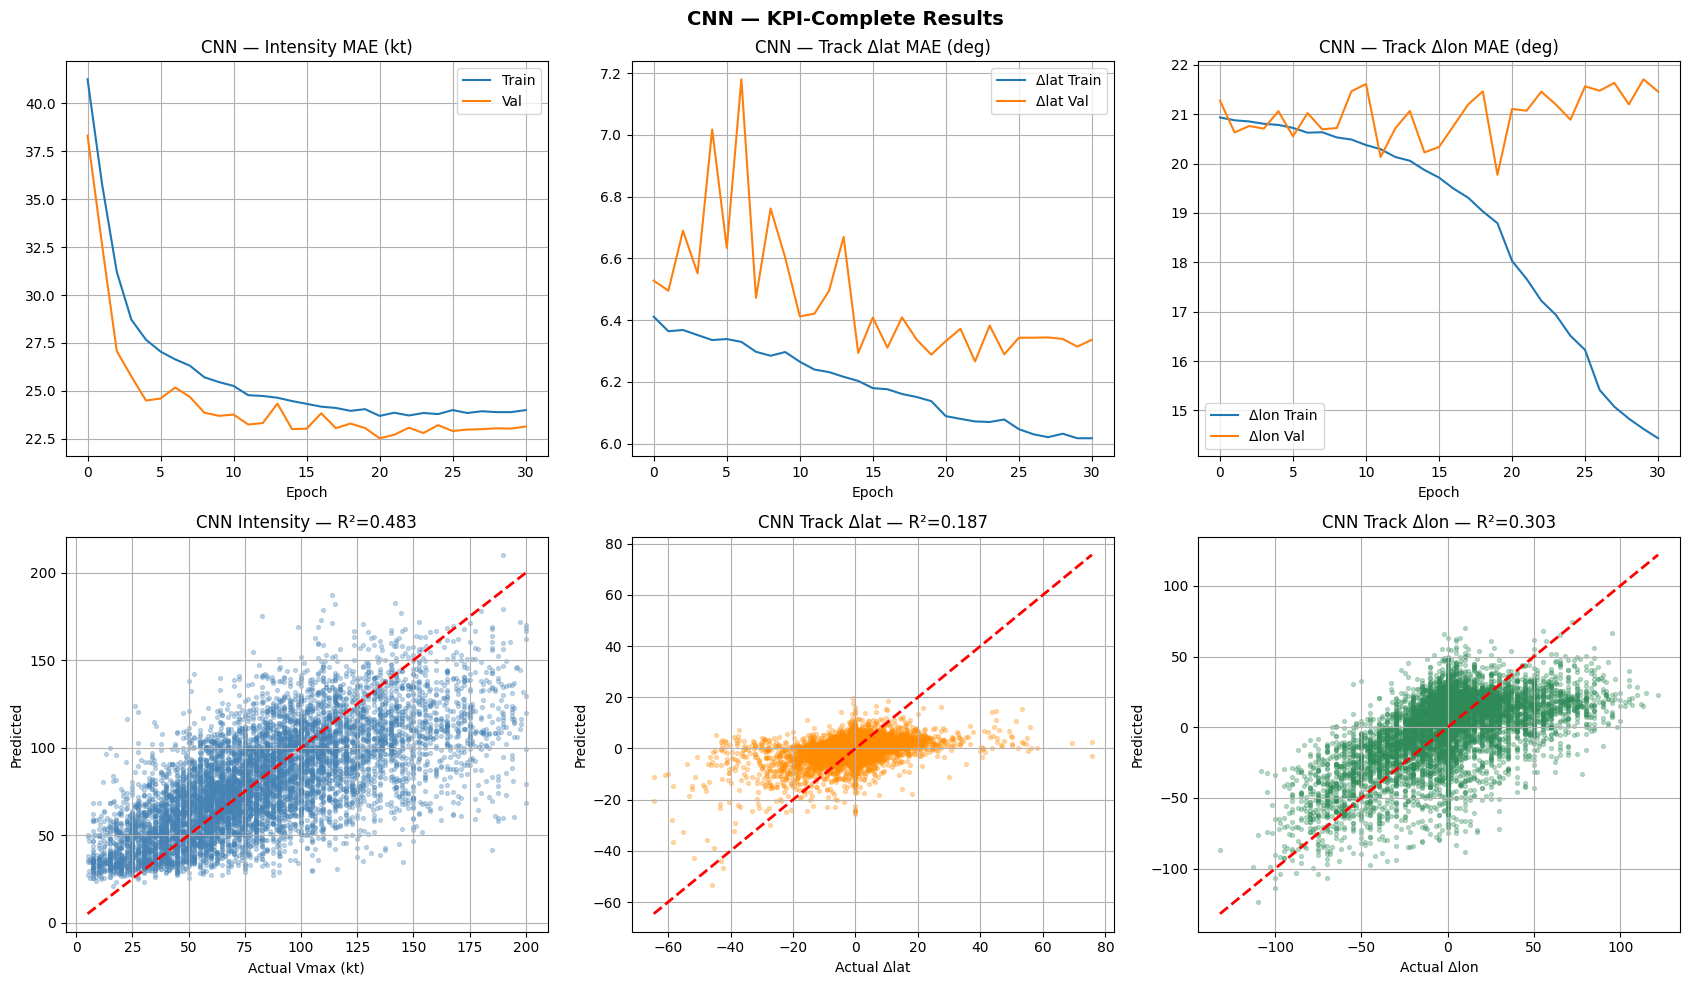

In [22]:
# ── Collect test targets ───────────────────────────────────────
y_test_vmax = y_vmax[te_idx]
y_test_dlat = dlat[te_idx]
y_test_dlon = dlon[te_idx]

# ── Predict ───────────────────────────────────────────────────
preds_cnn = cnn_model.predict(cnn_test_gen, verbose=0)
p_vmax_cnn = preds_cnn[0].flatten()
p_dlat_cnn = preds_cnn[1].flatten()
p_dlon_cnn = preds_cnn[2].flatten()

# ── Metrics ───────────────────────────────────────────────────
def metrics(y_true, y_pred, label):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    r2   = r2_score(y_true, y_pred)
    print(f'  {label}: MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}')
    return mae, rmse, r2

print('\n--- CNN Test Results ---')
cnn_vmax_mae, cnn_vmax_rmse, cnn_vmax_r2 = metrics(y_test_vmax, p_vmax_cnn, 'Intensity (vmax, kt)')
cnn_dlat_mae, cnn_dlat_rmse, cnn_dlat_r2 = metrics(y_test_dlat, p_dlat_cnn, 'Track Δlat (deg)')
cnn_dlon_mae, cnn_dlon_rmse, cnn_dlon_r2 = metrics(y_test_dlon, p_dlon_cnn, 'Track Δlon (deg)')

# ── Track error in km ─────────────────────────────────────────
dlat_err = y_test_dlat - p_dlat_cnn
dlon_err = y_test_dlon - p_dlon_cnn
# Approximate 1 deg lat = 111 km, 1 deg lon = 111 * cos(mean_lat) km
mean_lat_rad = np.radians(np.abs(y_lats[te_idx]).mean())
track_err_km = np.sqrt((dlat_err * 111)**2 + (dlon_err * 111 * np.cos(mean_lat_rad))**2)
print(f'  Track error: {track_err_km.mean():.1f} km (mean) | {np.median(track_err_km):.1f} km (median)')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Training curves
axes[0,0].plot(cnn_history.history['vmax_out_mae'], label='Train')
axes[0,0].plot(cnn_history.history['val_vmax_out_mae'], label='Val')
axes[0,0].set_title('CNN — Intensity MAE (kt)')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(cnn_history.history['dlat_out_mae'], label='Δlat Train')
axes[0,1].plot(cnn_history.history['val_dlat_out_mae'], label='Δlat Val')
axes[0,1].set_title('CNN — Track Δlat MAE (deg)')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(cnn_history.history['dlon_out_mae'], label='Δlon Train')
axes[0,2].plot(cnn_history.history['val_dlon_out_mae'], label='Δlon Val')
axes[0,2].set_title('CNN — Track Δlon MAE (deg)')
axes[0,2].set_xlabel('Epoch'); axes[0,2].legend(); axes[0,2].grid(True)

# Scatter: Actual vs Predicted
axes[1,0].scatter(y_test_vmax, p_vmax_cnn, alpha=0.3, s=8, color='steelblue')
lims = [y_test_vmax.min(), y_test_vmax.max()]
axes[1,0].plot(lims, lims, 'r--', lw=2)
axes[1,0].set_xlabel('Actual Vmax (kt)'); axes[1,0].set_ylabel('Predicted')
axes[1,0].set_title(f'CNN Intensity — R²={cnn_vmax_r2:.3f}')
axes[1,0].grid(True)

axes[1,1].scatter(y_test_dlat, p_dlat_cnn, alpha=0.3, s=8, color='darkorange')
lims = [y_test_dlat.min(), y_test_dlat.max()]
axes[1,1].plot(lims, lims, 'r--', lw=2)
axes[1,1].set_xlabel('Actual Δlat'); axes[1,1].set_ylabel('Predicted')
axes[1,1].set_title(f'CNN Track Δlat — R²={cnn_dlat_r2:.3f}')
axes[1,1].grid(True)

axes[1,2].scatter(y_test_dlon, p_dlon_cnn, alpha=0.3, s=8, color='seagreen')
lims = [y_test_dlon.min(), y_test_dlon.max()]
axes[1,2].plot(lims, lims, 'r--', lw=2)
axes[1,2].set_xlabel('Actual Δlon'); axes[1,2].set_ylabel('Predicted')
axes[1,2].set_title(f'CNN Track Δlon — R²={cnn_dlon_r2:.3f}')
axes[1,2].grid(True)

plt.suptitle('CNN — KPI-Complete Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 12 — ConvLSTM Generator (4-frame sequences + scalars)

Each sequence yields:
- **Image sequence:** `(B, 4, 64, 64, 4)` — 4 consecutive satellite frames
- **Scalar sequence:** `(B, 4, 11)` — 4 consecutive scalar KPI vectors
- **Targets:** vmax, dlat, dlon of the **last** frame in the sequence

In [26]:
SEQ_LEN    = 4
BATCH_SIZE = 32

def build_convlstm_sequences(x_data, scalar_features, storm_ids, timestamps, valid_storms, seq_len=4):
    """Pre-build sequence index arrays for a given storm split."""
    valid_indices = []
    for s_id in valid_storms:
        idx = np.where(storm_ids == s_id)[0]
        idx = idx[np.argsort(timestamps[idx])]
        for i in range(len(idx) - seq_len + 1):
            valid_indices.append(idx[i : i + seq_len])
    return np.array(valid_indices)  # (N_seq, seq_len)


def make_convlstm_dataset(valid_indices, x_data, scalar_features,
                          y_vmax, y_dlat, y_dlon, shuffle=True):
    indexes = np.arange(len(valid_indices))

    def generator():
        idxs = np.random.permutation(indexes) if shuffle else indexes
        for i in range(0, len(idxs), BATCH_SIZE):
            bi     = idxs[i : i + BATCH_SIZE]
            blocks = valid_indices[bi]          # (B, seq_len)
            B      = len(blocks)

            img_seq    = np.empty((B, SEQ_LEN,
                                   x_data.shape[1], x_data.shape[2], x_data.shape[3]),
                                  dtype=np.float32)
            scalar_seq = np.empty((B, SEQ_LEN, scalar_features.shape[1]), dtype=np.float32)

            for j, block in enumerate(blocks):
                img_seq[j]    = x_data[block]
                scalar_seq[j] = scalar_features[block]

            last = blocks[:, -1]
            yield (
                (img_seq, scalar_seq),
                (y_vmax[last].astype(np.float32),
                 y_dlat[last].astype(np.float32),
                 y_dlon[last].astype(np.float32))
            )

    img_shape    = x_data.shape[1:]          # e.g. (64, 64, 4)
    scalar_shape = scalar_features.shape[1:] # e.g. (11,)

    output_signature = (
        (
            tf.TensorSpec(shape=(None, SEQ_LEN, *img_shape),    dtype=tf.float32),
            tf.TensorSpec(shape=(None, SEQ_LEN, *scalar_shape), dtype=tf.float32),
        ),
        (
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
        ),
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=output_signature)
    if shuffle:
        ds = ds.shuffle(buffer_size=10)
    return ds.prefetch(tf.data.AUTOTUNE)


print('Initializing ConvLSTM generators...')
print('Train:')
tr_vi = build_convlstm_sequences(x_data, scalar_features, storm_ids, timestamps, tr_s, SEQ_LEN)
print(f'  Total sequences: {len(tr_vi)}')
print('Val:')
va_vi = build_convlstm_sequences(x_data, scalar_features, storm_ids, timestamps, va_s, SEQ_LEN)
print(f'  Total sequences: {len(va_vi)}')
print('Test:')
te_vi = build_convlstm_sequences(x_data, scalar_features, storm_ids, timestamps, te_s, SEQ_LEN)
print(f'  Total sequences: {len(te_vi)}')

lstm_train_gen = make_convlstm_dataset(tr_vi, x_data, scalar_features, y_vmax, dlat, dlon, shuffle=True)
lstm_val_gen   = make_convlstm_dataset(va_vi, x_data, scalar_features, y_vmax, dlat, dlon, shuffle=False)
lstm_test_gen  = make_convlstm_dataset(te_vi, x_data, scalar_features, y_vmax, dlat, dlon, shuffle=False)

# Keep valid_indices accessible for cell 15 (needed to extract last indices)
class _GenMeta:
    def __init__(self, vi): self.valid_indices = vi

lstm_test_gen_meta = _GenMeta(te_vi)

Initializing ConvLSTM generators...
Train:
  Total sequences: 22659
Val:
  Total sequences: 2269
Test:
  Total sequences: 5705


## Cell 13 — Build KPI-Complete ConvLSTM

**Architecture:**
- **Image-sequence branch:** 2-layer ConvLSTM2D → spatial feature extraction
- **Scalar-sequence branch:** TimeDistributed Dense → LSTM(64) — captures temporal KPI evolution (ENSO, MJO, shear, translation)
- **Fusion:** Concatenate → Dense(256) → Dropout
- **Outputs (3 heads):** vmax, dlat, dlon

In [27]:
def build_kpi_convlstm(seq_len=4, image_shape=(64, 64, 4), n_scalars=11):
    # ── Image-sequence branch ──────────────────────────────────
    img_seq_input = Input(shape=(seq_len, *image_shape), name='img_seq_input')

    x = layers.ConvLSTM2D(32, (3,3), padding='same', return_sequences=True,
                           activation='relu', name='convlstm1')(img_seq_input)
    x = layers.BatchNormalization()(x)
    x = layers.ConvLSTM2D(64, (3,3), padding='same', return_sequences=False,
                           activation='relu', name='convlstm2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    img_feat = layers.GlobalAveragePooling2D(name='img_seq_feat')(x)
    img_feat = layers.Dense(256, activation='relu')(img_feat)

    # ── Scalar-sequence branch ─────────────────────────────────
    # Captures how KPI scalars evolve over the 4-frame window
    scalar_seq_input = Input(shape=(seq_len, n_scalars), name='scalar_seq_input')
    s = layers.TimeDistributed(layers.Dense(32, activation='relu'))(scalar_seq_input)
    s = layers.LSTM(64, name='scalar_lstm')(s)
    scalar_feat = layers.Dense(32, activation='relu', name='scalar_seq_feat')(s)

    # ── Fusion ─────────────────────────────────────────────────
    fused = layers.Concatenate(name='fusion')([img_feat, scalar_feat])
    fused = layers.Dense(256, activation='relu')(fused)
    fused = layers.Dropout(0.4)(fused)
    fused = layers.Dense(128, activation='relu')(fused)

    # ── Output heads ───────────────────────────────────────────
    vmax_out = layers.Dense(1, activation='linear', name='vmax_out')(fused)
    dlat_out = layers.Dense(1, activation='linear', name='dlat_out')(fused)
    dlon_out = layers.Dense(1, activation='linear', name='dlon_out')(fused)

    model = tf.keras.Model(
        inputs=[img_seq_input, scalar_seq_input],
        outputs=[vmax_out, dlat_out, dlon_out]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(5e-4),
        loss={
            'vmax_out': tf.keras.losses.Huber(),
            'dlat_out': 'mse',
            'dlon_out': 'mse',
        },
        loss_weights={'vmax_out': 1.0, 'dlat_out': 10.0, 'dlon_out': 10.0},
        metrics={'vmax_out': ['mae'], 'dlat_out': ['mae'], 'dlon_out': ['mae']}
    )
    return model

convlstm_model = build_kpi_convlstm()
print('KPI-Complete ConvLSTM built (dual-input, 3-output heads).')
convlstm_model.summary()

KPI-Complete ConvLSTM built (dual-input, 3-output heads).


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_seq_input       │ (None, 4, 64, 64, │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convlstm1           │ (None, 4, 64, 64, │     41,600 │ img_seq_input[0]… │
│ (ConvLSTM2D)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 64, 64, │        128 │ convlstm1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convlstm2           │ (None, 64, 64,    │    221,440 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ convlstm2[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalar_seq_input    │ (None, 4, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 4, 32)     │        384 │ scalar_seq_input… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_seq_feat        │ (None, 64)        │          0 │ max_pooling2d_13… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalar_lstm (LSTM)  │ (None, 64)        │     24,832 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 256)       │     16,640 │ img_seq_feat[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalar_seq_feat     │ (None, 32)        │      2,080 │ scalar_lstm[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 288)       │          0 │ dense_20[0][0],   │
│ (Concatenate)       │                   │            │ scalar_seq_feat[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 256)       │     73,984 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 128)       │     32,896 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vmax_out (Dense)    │ (None, 1)         │        129 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlat_out (Dense)    │ (None, 1)         │        129 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlon_out (Dense)    │ (None, 1)         │        129 │ dense_23[0][0]    │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 414,627 (1.58 MB)

 Trainable params: 414,435 (1.58 MB)

 Non-trainable params: 192 (768.00 B)

## Cell 14 — Train ConvLSTM

In [28]:
lstm_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_vmax_out_mae', patience=15, min_delta=0.15,
        restore_best_weights=True, verbose=1, mode='min'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_vmax_out_mae', factor=0.5, patience=5,
        min_delta=0.1, min_lr=1e-6, verbose=1, mode='min'
    ),
    tf.keras.callbacks.TerminateOnNaN()
]

print('Training KPI-ConvLSTM (up to 60 epochs)...')
lstm_history = convlstm_model.fit(
    lstm_train_gen,
    validation_data=lstm_val_gen,
    epochs=60,
    callbacks=lstm_callbacks,
    verbose=1
)

Training KPI-ConvLSTM (up to 60 epochs)...
Epoch 1/60
    709/Unknown 300s 402ms/step - dlat_out_loss: 82.3669 - dlat_out_mae: 5.9662 - dlon_out_loss: 886.9092 - dlon_out_mae: 21.8316 - loss: 9758.9047 - vmax_out_loss: 66.1166 - vmax_out_mae: 66.6155

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


709/709 ━━━━━━━━━━━━━━━━━━━━ 311s 417ms/step - dlat_out_loss: 78.7691 - dlat_out_mae: 5.8895 - dlon_out_loss: 787.2846 - dlon_out_mae: 21.4957 - loss: 8725.6973 - vmax_out_loss: 51.0624 - vmax_out_mae: 51.6398 - val_dlat_out_loss: 82.7674 - val_dlat_out_mae: 6.0615 - val_dlon_out_loss: 699.4007 - val_dlon_out_mae: 20.7929 - val_loss: 7967.3594 - val_vmax_out_loss: 30.1451 - val_vmax_out_mae: 31.0691 - learning_rate: 5.0000e-04
Epoch 2/60
709/709 ━━━━━━━━━━━━━━━━━━━━ 293s 413ms/step - dlat_out_loss: 78.2373 - dlat_out_mae: 5.8910 - dlon_out_loss: 710.9161 - dlon_out_mae: 21.0377 - loss: 7921.0615 - vmax_out_loss: 32.7767 - vmax_out_mae: 33.3496 - val_dlat_out_loss: 81.9279 - val_dlat_out_mae: 6.0798 - val_dlon_out_loss: 702.3851 - val_dlon_out_mae: 21.8510 - val_loss: 7987.9937 - val_vmax_out_loss: 30.2550 - val_vmax_out_mae: 31.1796 - learning_rate: 5.0000e-04
Epoch 3/60
709/709 ━━━━━━━━━━━━━━━━━━━━ 292s 412ms/step - dlat_out_loss: 76.9496 - dlat_out_mae: 5.8887 - dlon_out_loss: 697.71

## Cell 15 — Evaluate ConvLSTM (Intensity + Track)


--- ConvLSTM Test Results ---
  Intensity (vmax, kt): MAE=25.745 | RMSE=33.473 | R²=0.341
  Track Δlat (deg): MAE=5.463 | RMSE=7.741 | R²=0.191
  Track Δlon (deg): MAE=21.222 | RMSE=27.698 | R²=0.277
  Track error: 2408.2 km (mean) | 1968.1 km (median)


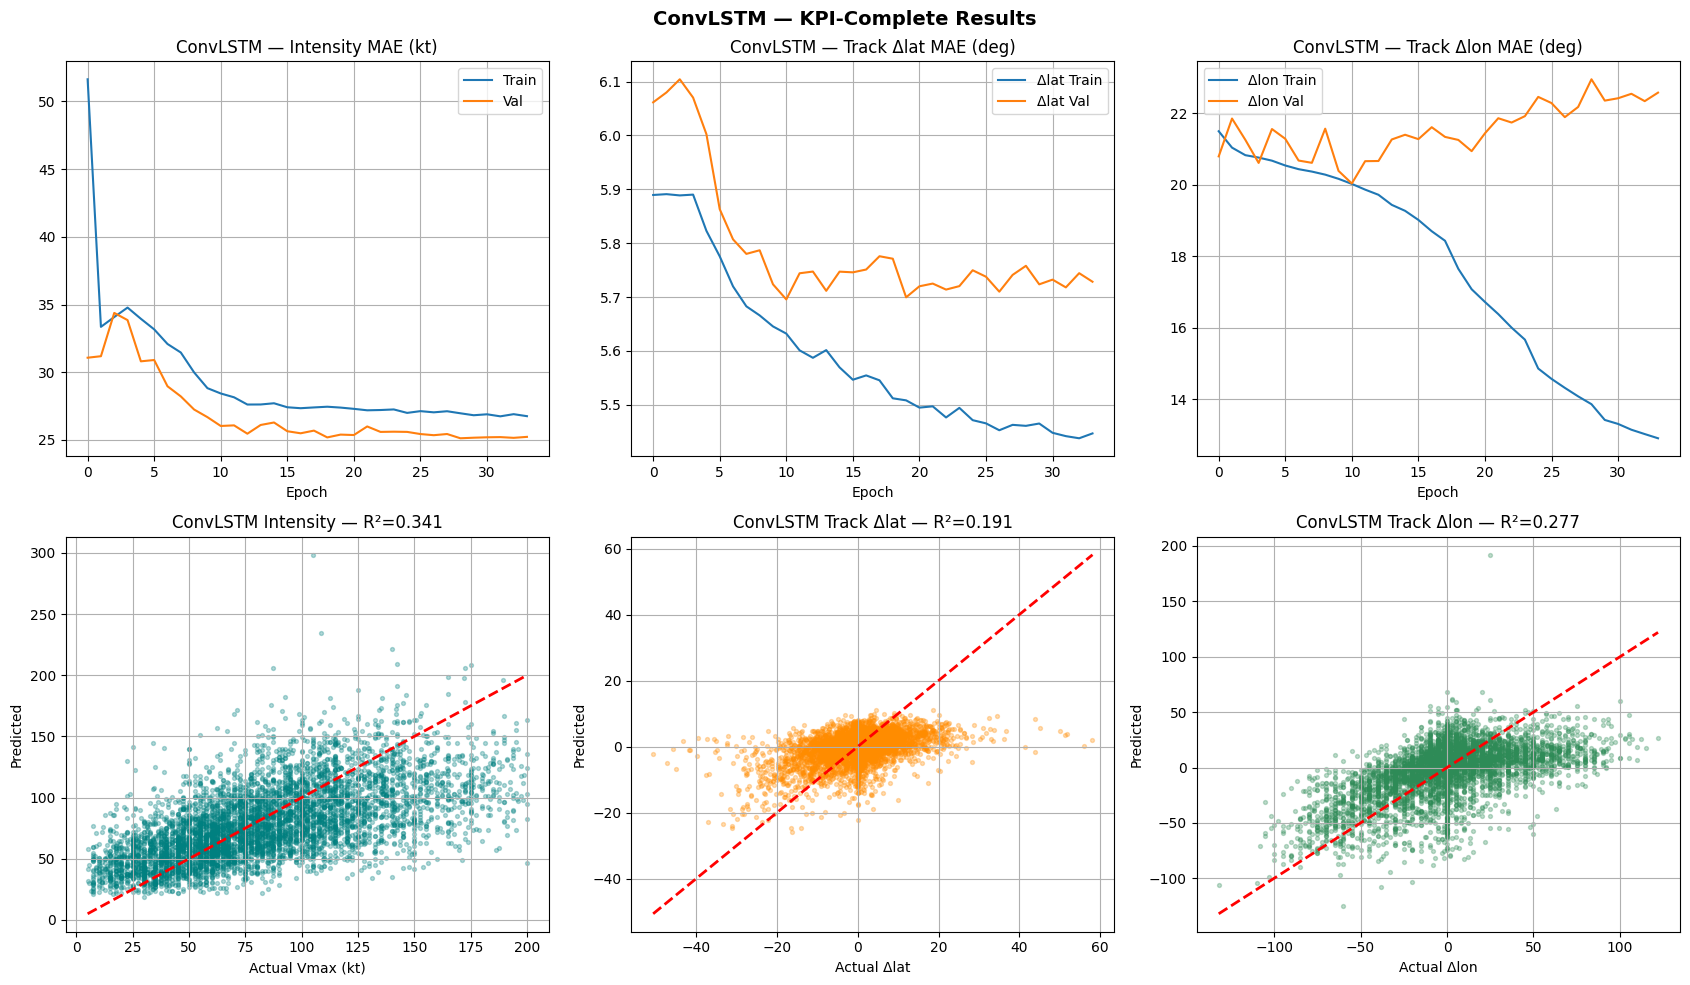

In [29]:
# ── Collect test targets from ConvLSTM generator ──────────────
last_indices = lstm_test_gen_meta.valid_indices[:, -1]
y_te_vmax    = y_vmax[last_indices]
y_te_dlat    = dlat[last_indices]
y_te_dlon    = dlon[last_indices]

# ── Predict ───────────────────────────────────────────────────
preds_lstm    = convlstm_model.predict(lstm_test_gen, verbose=0)
p_vmax_lstm   = preds_lstm[0].flatten()
p_dlat_lstm   = preds_lstm[1].flatten()
p_dlon_lstm   = preds_lstm[2].flatten()

print('\n--- ConvLSTM Test Results ---')
lstm_vmax_mae, lstm_vmax_rmse, lstm_vmax_r2 = metrics(y_te_vmax, p_vmax_lstm, 'Intensity (vmax, kt)')
lstm_dlat_mae, lstm_dlat_rmse, lstm_dlat_r2 = metrics(y_te_dlat, p_dlat_lstm, 'Track Δlat (deg)')
lstm_dlon_mae, lstm_dlon_rmse, lstm_dlon_r2 = metrics(y_te_dlon, p_dlon_lstm, 'Track Δlon (deg)')

dlat_err_l = y_te_dlat - p_dlat_lstm
dlon_err_l = y_te_dlon - p_dlon_lstm
mean_lat_rad_l = np.radians(np.abs(y_lats[last_indices]).mean())
track_err_km_l = np.sqrt((dlat_err_l * 111)**2 + (dlon_err_l * 111 * np.cos(mean_lat_rad_l))**2)
print(f'  Track error: {track_err_km_l.mean():.1f} km (mean) | {np.median(track_err_km_l):.1f} km (median)')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

axes[0,0].plot(lstm_history.history['vmax_out_mae'], label='Train')
axes[0,0].plot(lstm_history.history['val_vmax_out_mae'], label='Val')
axes[0,0].set_title('ConvLSTM — Intensity MAE (kt)')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(lstm_history.history['dlat_out_mae'], label='Δlat Train')
axes[0,1].plot(lstm_history.history['val_dlat_out_mae'], label='Δlat Val')
axes[0,1].set_title('ConvLSTM — Track Δlat MAE (deg)')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(lstm_history.history['dlon_out_mae'], label='Δlon Train')
axes[0,2].plot(lstm_history.history['val_dlon_out_mae'], label='Δlon Val')
axes[0,2].set_title('ConvLSTM — Track Δlon MAE (deg)')
axes[0,2].set_xlabel('Epoch'); axes[0,2].legend(); axes[0,2].grid(True)

axes[1,0].scatter(y_te_vmax, p_vmax_lstm, alpha=0.3, s=8, color='teal')
lims = [y_te_vmax.min(), y_te_vmax.max()]
axes[1,0].plot(lims, lims, 'r--', lw=2)
axes[1,0].set_xlabel('Actual Vmax (kt)'); axes[1,0].set_ylabel('Predicted')
axes[1,0].set_title(f'ConvLSTM Intensity — R²={lstm_vmax_r2:.3f}')
axes[1,0].grid(True)

axes[1,1].scatter(y_te_dlat, p_dlat_lstm, alpha=0.3, s=8, color='darkorange')
lims = [y_te_dlat.min(), y_te_dlat.max()]
axes[1,1].plot(lims, lims, 'r--', lw=2)
axes[1,1].set_xlabel('Actual Δlat'); axes[1,1].set_ylabel('Predicted')
axes[1,1].set_title(f'ConvLSTM Track Δlat — R²={lstm_dlat_r2:.3f}')
axes[1,1].grid(True)

axes[1,2].scatter(y_te_dlon, p_dlon_lstm, alpha=0.3, s=8, color='seagreen')
lims = [y_te_dlon.min(), y_te_dlon.max()]
axes[1,2].plot(lims, lims, 'r--', lw=2)
axes[1,2].set_xlabel('Actual Δlon'); axes[1,2].set_ylabel('Predicted')
axes[1,2].set_title(f'ConvLSTM Track Δlon — R²={lstm_dlon_r2:.3f}')
axes[1,2].grid(True)

plt.suptitle('ConvLSTM — KPI-Complete Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 16 — Final Comparison Table (CNN vs ConvLSTM)

In [30]:
print('\n' + '=' * 85)
print('      MODEL COMPARISON — KPI-Complete CNN vs ConvLSTM')
print('=' * 85)
print(f'{"Task":<26} {"Metric":<8} {"CNN":>10} {"ConvLSTM":>12}')
print('-' * 85)

rows = [
    ('Intensity (vmax, kt)',  'MAE',  cnn_vmax_mae,  lstm_vmax_mae),
    ('Intensity (vmax, kt)',  'RMSE', cnn_vmax_rmse, lstm_vmax_rmse),
    ('Intensity (vmax, kt)',  'R²',   cnn_vmax_r2,   lstm_vmax_r2),
    ('Track Δlat (deg)',      'MAE',  cnn_dlat_mae,  lstm_dlat_mae),
    ('Track Δlat (deg)',      'R²',   cnn_dlat_r2,   lstm_dlat_r2),
    ('Track Δlon (deg)',      'MAE',  cnn_dlon_mae,  lstm_dlon_mae),
    ('Track Δlon (deg)',      'R²',   cnn_dlon_r2,   lstm_dlon_r2),
    ('Track error (km)',      'Mean', track_err_km.mean(), track_err_km_l.mean()),
]

for task, metric, cnn_val, lstm_val in rows:
    better = 'CNN' if (
        (metric in ('MAE','RMSE','Mean') and cnn_val < lstm_val) or
        (metric == 'R²' and cnn_val > lstm_val)
    ) else 'ConvLSTM'
    mark_c = ' <' if better == 'CNN' else ''
    mark_l = ' <' if better == 'ConvLSTM' else ''
    print(f'{task:<26} {metric:<8} {cnn_val:>10.3f}{mark_c:<2} {lstm_val:>12.3f}{mark_l}')

print('=' * 85)
print('< = better model for that metric')


      MODEL COMPARISON — KPI-Complete CNN vs ConvLSTM
Task                       Metric          CNN     ConvLSTM
-------------------------------------------------------------------------------------
Intensity (vmax, kt)       MAE          22.415 <       25.745
Intensity (vmax, kt)       RMSE         29.340 <       33.473
Intensity (vmax, kt)       R²            0.483 <        0.341
Track Δlat (deg)           MAE           5.968          5.463 <
Track Δlat (deg)           R²            0.187          0.191 <
Track Δlon (deg)           MAE          21.025 <       21.222
Track Δlon (deg)           R²            0.303 <        0.277
Track error (km)           Mean       2430.471       2408.157 <
< = better model for that metric


## Cell 17 — Intensity Bias Analysis & Cyclone Occurrence

          BIAS ANALYSIS — INTENSITY

CNN:
  Mean bias : -2.72 kt
  Std       : 29.21 kt
  Over-pred : 51.3%
  Under-pred: 48.7%

ConvLSTM:
  Mean bias : -4.94 kt
  Std       : 33.11 kt
  Over-pred : 47.3%
  Under-pred: 52.7%

       INTENSITY-BINNED BIAS
Category                 CNN bias    LSTM bias      N
-----------------------------------------------------------------
TD/TS (<34 kt)             +23.10       +26.00    920
Cat 1 (34–64)              +11.70       +10.93   2133
Cat 2-3 (64–96)             +0.73        -0.48   2312
Major (>96 kt)             -24.99       -29.28   2779

  CYCLONE OCCURRENCE ACCURACY (bias-corrected)

CNN:
  Accuracy: 89.4%
              precision    recall  f1-score   support

  No Cyclone       0.69      0.11      0.19       920
     Cyclone       0.90      0.99      0.94      7233

    accuracy                           0.89      8153
   macro avg       0.79      0.55      0.57      8153
weighted avg       0.87      0.89      0.86      8153


ConvLSTM:

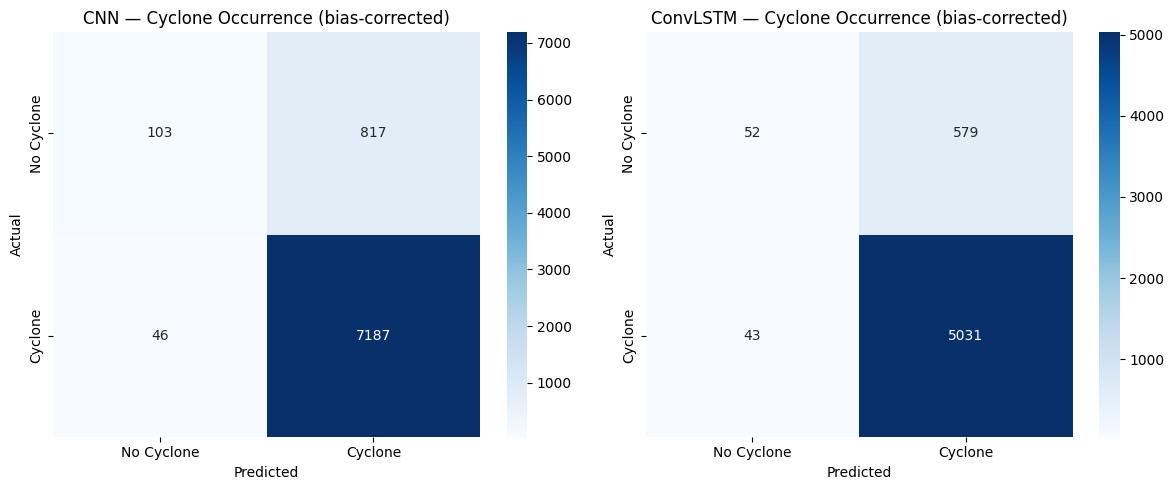

In [31]:
CYCLONE_THRESHOLD = 34.0  # kt — tropical storm threshold

errors_cnn  = p_vmax_cnn  - y_test_vmax
errors_lstm = p_vmax_lstm - y_te_vmax

print('=' * 65)
print('          BIAS ANALYSIS — INTENSITY')
print('=' * 65)
for name, err in [('CNN', errors_cnn), ('ConvLSTM', errors_lstm)]:
    print(f'\n{name}:')
    print(f'  Mean bias : {err.mean():+.2f} kt')
    print(f'  Std       : {err.std():.2f} kt')
    print(f'  Over-pred : {(err > 0).mean()*100:.1f}%')
    print(f'  Under-pred: {(err < 0).mean()*100:.1f}%')

# Intensity-binned bias
bins       = [0, 34, 64, 96, 200]
bin_labels = ['TD/TS (<34 kt)', 'Cat 1 (34–64)', 'Cat 2-3 (64–96)', 'Major (>96 kt)']

print('\n' + '=' * 65)
print('       INTENSITY-BINNED BIAS')
print('=' * 65)
print(f'{"Category":<22} {"CNN bias":>10} {"LSTM bias":>12} {"N":>6}')
print('-' * 65)
for i in range(len(bins)-1):
    mask_c = (y_test_vmax >= bins[i]) & (y_test_vmax < bins[i+1])
    mask_l = (y_te_vmax  >= bins[i]) & (y_te_vmax  < bins[i+1])
    bc = errors_cnn[mask_c].mean()  if mask_c.sum() > 0 else float('nan')
    bl = errors_lstm[mask_l].mean() if mask_l.sum() > 0 else float('nan')
    print(f'{bin_labels[i]:<22} {bc:>+10.2f} {bl:>+12.2f} {mask_c.sum():>6}')

# Bias-corrected occurrence
bias_cnn  = errors_cnn.mean()
bias_lstm = errors_lstm.mean()
p_cnn_adj  = p_vmax_cnn  - bias_cnn
p_lstm_adj = p_vmax_lstm - bias_lstm

print('\n' + '=' * 65)
print('  CYCLONE OCCURRENCE ACCURACY (bias-corrected)')
print('=' * 65)
for name, pred, ytrue in [('CNN', p_cnn_adj, y_test_vmax), ('ConvLSTM', p_lstm_adj, y_te_vmax)]:
    occ  = (pred  >= CYCLONE_THRESHOLD).astype(int)
    true = (ytrue >= CYCLONE_THRESHOLD).astype(int)
    acc  = (occ == true).mean()
    print(f'\n{name}:')
    print(f'  Accuracy: {acc*100:.1f}%')
    print(classification_report(true, occ, target_names=['No Cyclone', 'Cyclone']))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, pred, ytrue in [
    (axes[0], 'CNN',      p_cnn_adj,  y_test_vmax),
    (axes[1], 'ConvLSTM', p_lstm_adj, y_te_vmax)
]:
    occ  = (pred  >= CYCLONE_THRESHOLD).astype(int)
    true = (ytrue >= CYCLONE_THRESHOLD).astype(int)
    cm   = confusion_matrix(true, occ)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Cyclone','Cyclone'], yticklabels=['No Cyclone','Cyclone'])
    ax.set_title(f'{name} — Cyclone Occurrence (bias-corrected)')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## Cell 18 — Track Visualization: Actual vs Predicted Storm Paths

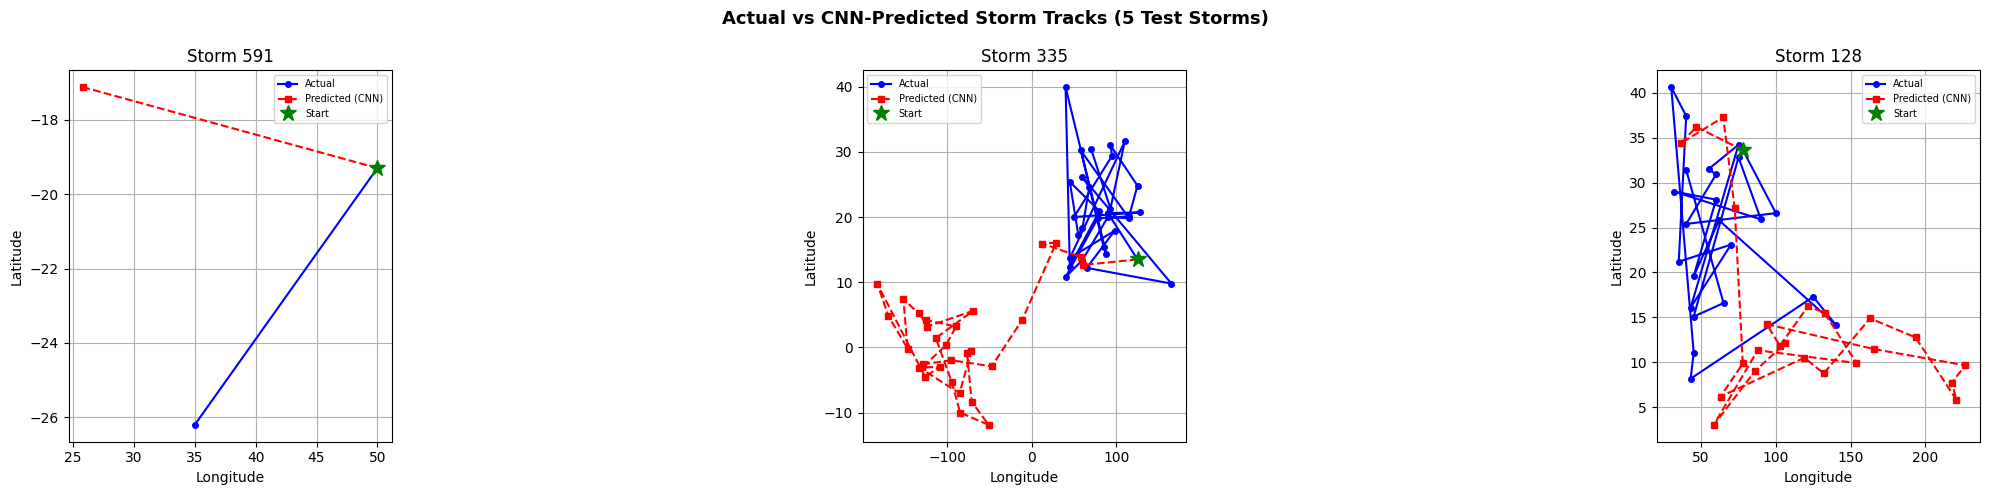

In [32]:
# Reconstruct 6-step cumulative tracks for 5 test storms
# Using ConvLSTM predictions (best sequential model)

N_STORMS_PLOT = 5
test_storm_list = list(te_s[:N_STORMS_PLOT])

fig, axes = plt.subplots(1, N_STORMS_PLOT, figsize=(20, 5))

for ax, sid in zip(axes, test_storm_list):
    idx = np.where(storm_ids == sid)[0]
    idx = idx[np.argsort(timestamps[idx])]

    if len(idx) < 2:
        ax.set_visible(False)
        continue

    actual_lats = y_lats[idx]
    actual_lons = y_lons[idx]

    # Simulate 1-step-ahead predicted track using CNN dlat/dlon predictions
    # Start from first observed position
    pred_lats = [actual_lats[0]]
    pred_lons = [actual_lons[0]]
    for k in range(len(idx) - 1):
        # Get CNN prediction for this observation
        obs_i = idx[k]
        # Find this observation in te_idx
        te_match = np.where(te_idx == obs_i)[0]
        if len(te_match) > 0:
            j = te_match[0]
            pred_dlat = p_dlat_cnn[j] if j < len(p_dlat_cnn) else dlat[obs_i]
            pred_dlon = p_dlon_cnn[j] if j < len(p_dlon_cnn) else dlon[obs_i]
        else:
            pred_dlat = dlat[obs_i]
            pred_dlon = dlon[obs_i]
        pred_lats.append(pred_lats[-1] + pred_dlat)
        pred_lons.append(pred_lons[-1] + pred_dlon)

    pred_lats = np.array(pred_lats)
    pred_lons = np.array(pred_lons)

    ax.plot(actual_lons, actual_lats, 'b-o', markersize=4, label='Actual', linewidth=1.5)
    ax.plot(pred_lons,   pred_lats,   'r--s', markersize=4, label='Predicted (CNN)', linewidth=1.5)
    ax.plot(actual_lons[0], actual_lats[0], 'g*', markersize=12, label='Start')

    ax.set_title(f'Storm {int(sid)}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('Actual vs CNN-Predicted Storm Tracks (5 Test Storms)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 19 — KPI Scalar Feature Importance

Measures how much each KPI scalar contributes to CNN intensity prediction by permutation importance.

Computing permutation importance (this takes a moment)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  MCP (pressure)            : ΔMAE = +13.733 kt
  RMW proxy                 : ΔMAE = +0.106 kt
  Wind shear proxy          : ΔMAE = +0.330 kt
  SST mean (IR ch0)         : ΔMAE = +0.260 kt
  Translation speed         : ΔMAE = +0.202 kt
  Translation dir (sin)     : ΔMAE = +0.033 kt
  Translation dir (cos)     : ΔMAE = +0.236 kt
  ENSO (Niño3.4)            : ΔMAE = +0.000 kt
  MJO phase (sin)           : ΔMAE = +0.000 kt
  MJO phase (cos)           : ΔMAE = +0.000 kt
  MJO amplitude             : ΔMAE = +0.000 kt


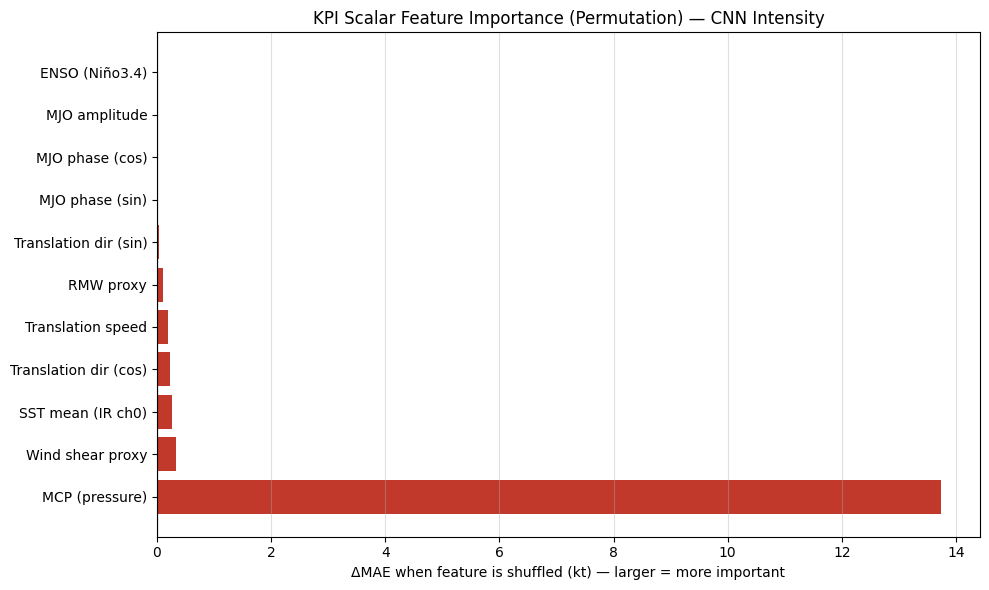

In [34]:
SCALAR_NAMES = [
    'MCP (pressure)', 'RMW proxy', 'Wind shear proxy', 'SST mean (IR ch0)',
    'Translation speed', 'Translation dir (sin)', 'Translation dir (cos)',
    'ENSO (Niño3.4)', 'MJO phase (sin)', 'MJO phase (cos)', 'MJO amplitude',
]

baseline_mae = cnn_vmax_mae

def make_perm_dataset(xi, sc_perm):
    def gen():
        for i in range(0, len(xi), 64):
            b      = xi[i:i+64]
            img    = x_data[b].astype(np.float32)
            scalar = sc_perm[i:i+64].astype(np.float32)
            yield {'image_input': img, 'scalar_input': scalar}

    return tf.data.Dataset.from_generator(
        gen,
        output_signature={
            'image_input':  tf.TensorSpec(shape=(None, *x_data.shape[1:]), dtype=tf.float32),
            'scalar_input': tf.TensorSpec(shape=(None, *sc_perm.shape[1:]), dtype=tf.float32),
        }
    ).prefetch(tf.data.AUTOTUNE)

print('Computing permutation importance (this takes a moment)...')
importances = []
np.random.seed(42)

for fi, fname in enumerate(SCALAR_NAMES):
    sc_perm = scalar_features[te_idx].copy()
    np.random.shuffle(sc_perm[:, fi])

    ds_perm    = make_perm_dataset(te_idx, sc_perm)
    preds_perm = cnn_model.predict(ds_perm, verbose=0)
    perm_mae   = np.mean(np.abs(preds_perm[0].flatten() - y_test_vmax))
    importances.append(perm_mae - baseline_mae)
    print(f'  {fname:<26}: ΔMAE = {perm_mae - baseline_mae:+.3f} kt')

# Plot
sort_idx = np.argsort(importances)[::-1]
fig, ax  = plt.subplots(figsize=(10, 6))
colors   = ['#c0392b' if v > 0 else '#2980b9' for v in np.array(importances)[sort_idx]]
ax.barh([SCALAR_NAMES[i] for i in sort_idx], [importances[i] for i in sort_idx], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ΔMAE when feature is shuffled (kt) — larger = more important')
ax.set_title('KPI Scalar Feature Importance (Permutation) — CNN Intensity')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## Cell 20 — Save Models

In [35]:
SAVE_DIR = '/content/drive/MyDrive/TCIR/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

cnn_model.save(os.path.join(SAVE_DIR, 'kpi_cnn_model.keras'))
convlstm_model.save(os.path.join(SAVE_DIR, 'kpi_convlstm_model.keras'))

print(f'Models saved to {SAVE_DIR}')
print(f'  kpi_cnn_model.keras')
print(f'  kpi_convlstm_model.keras')

Models saved to /content/drive/MyDrive/TCIR/saved_models
  kpi_cnn_model.keras
  kpi_convlstm_model.keras
